<!--
Software Name : learning-parities-with-product-networks
SPDX-FileCopyrightText: Copyright (c) 2026 Orange S.A.
SPDX-License-Identifier: MIT

This software is distributed under the MIT License .,
see the "LICENSE.md" file for more details or https://opensource.org/licenses/MIT

Author: Guillaume Larue, guillaume.larue@orange.com
Software description: Source code of the paper "Learning High-Dimensional Parity Functions with Product Networks"
-->

# Study H — Product Node vs MLP: Sparse vs Full-Table Training

Compares a **product node** with a standard **MLP** under two training regimes:

- **Sparse:** Bernouilli sampled inputs with $p_e = 1/N$ (very few active bits per example).
- **Full:** inputs sampled uniformly from the complete truth table ($2^N$ rows).

Both models are evaluated on the **full truth table** (generalisation accuracy).

**Data generated by:** [run_study_H.py](../studies/run_study_H.py)  
**Paper section:** Section 5.2.4 Generalization \& Comparison with MLP (Figure 6)

| Parameter | Value |
|-----------|-------|
| Problem Size $N$              | 16                        |
| Truth Table Size $2^N$        | 65 536                    |
| Num. Parallel Nodes.  $P$     | 250                       |
| Learning Rate $\alpha$    | 0.02                      |
| Batch Size $M$                | 100                       |
| Bernouilli Prob. $p_e$        | $1/N$ or uniform TT sampling     |
| Oracle Proportion $p_w$       | 0.5                       |
| Max. Steps $S$                | 1 000 000                 |
| MLP Architecture              | $N \to 512 \to 512 \to 64 \to 1$ |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import glob

sys.path.append('..')
from plotting.plot_utility import setup_plot_style

%matplotlib inline
setup_plot_style()

In [2]:
def get_latest_study_folder(study_prefix):
    pattern = f'../studies/results/{study_prefix}_*/'
    folders = glob.glob(pattern)
    if folders:
        return max(folders)  # Latest by name (timestamp-based)
    return None

mode = 'auto'  # Change to 'manual' to specify your own path

if mode == 'auto':
    results_dir = get_latest_study_folder('H_product_vs_mlp')
    if results_dir is None:
        raise FileNotFoundError("No Study H results found. Run run_study_H.py first.")
    print(f"Auto-detected folder: {results_dir}")
else:
    results_dir = '../studies/results/H_product_vs_mlp_XXXXXX_XXXXXX/'
    print(f"Using manual path: {results_dir}")

# ---- Load arrays ----
# Training accuracy on seen codewords
sparse_product_train_acc = np.load(results_dir + 'sparse_product_train_acc.npy')
sparse_mlp_train_acc     = np.load(results_dir + 'sparse_mlp_train_acc.npy')
full_product_train_acc   = np.load(results_dir + 'full_product_train_acc.npy')
full_mlp_train_acc       = np.load(results_dir + 'full_mlp_train_acc.npy')

# Validation accuracy on full truth table
sparse_product_val_acc = np.load(results_dir + 'sparse_product_val_acc.npy')
sparse_mlp_val_acc     = np.load(results_dir + 'sparse_mlp_val_acc.npy')
full_product_val_acc   = np.load(results_dir + 'full_product_val_acc.npy')
full_mlp_val_acc       = np.load(results_dir + 'full_mlp_val_acc.npy')

# Coverage and eval steps
sparse_coverage = np.load(results_dir + 'sparse_coverage.npy')
full_coverage   = np.load(results_dir + 'full_coverage.npy')
eval_steps      = np.load(results_dir + 'eval_steps.npy')

n_runs = sparse_product_train_acc.shape[0]

print(f"Loaded: {n_runs} runs, {len(eval_steps)} eval points")
print(f"Eval steps range: {eval_steps[0]:.0f} to {eval_steps[-1]:.0f}")
print(f"Sparse coverage (final): {100*sparse_coverage[:,-1].mean():.4f}%")
print(f"Full   coverage (final): {100*full_coverage[:,-1].mean():.2f}%")

Auto-detected folder: ../studies/results/H_product_vs_mlp_20260420_233719/
Loaded: 1 runs, 31 eval points
Eval steps range: 1 to 1000000
Sparse coverage (final): 25.5936%
Full   coverage (final): 100.00%


## Generalisation Accuracy — Sparse vs Full Training Regime

**Left (Sparse):** The product node generalises perfectly from very few examples ($\ll 1\%$ coverage), while the MLP overfits to the training set (discrepancies between training and validation accuracies).

**Right (Full):** With uniform sampling, both models eventually learn. The MLP is faster than the product node but requires complete coverage.

Solid lines = training accuracy (seen codewords). Dashed lines = validation accuracy (full truth table). Green dotted = coverage ($\%$ of $2^N$ unique inputs seen).

See Paper Section 5.2.4. Figure 6.

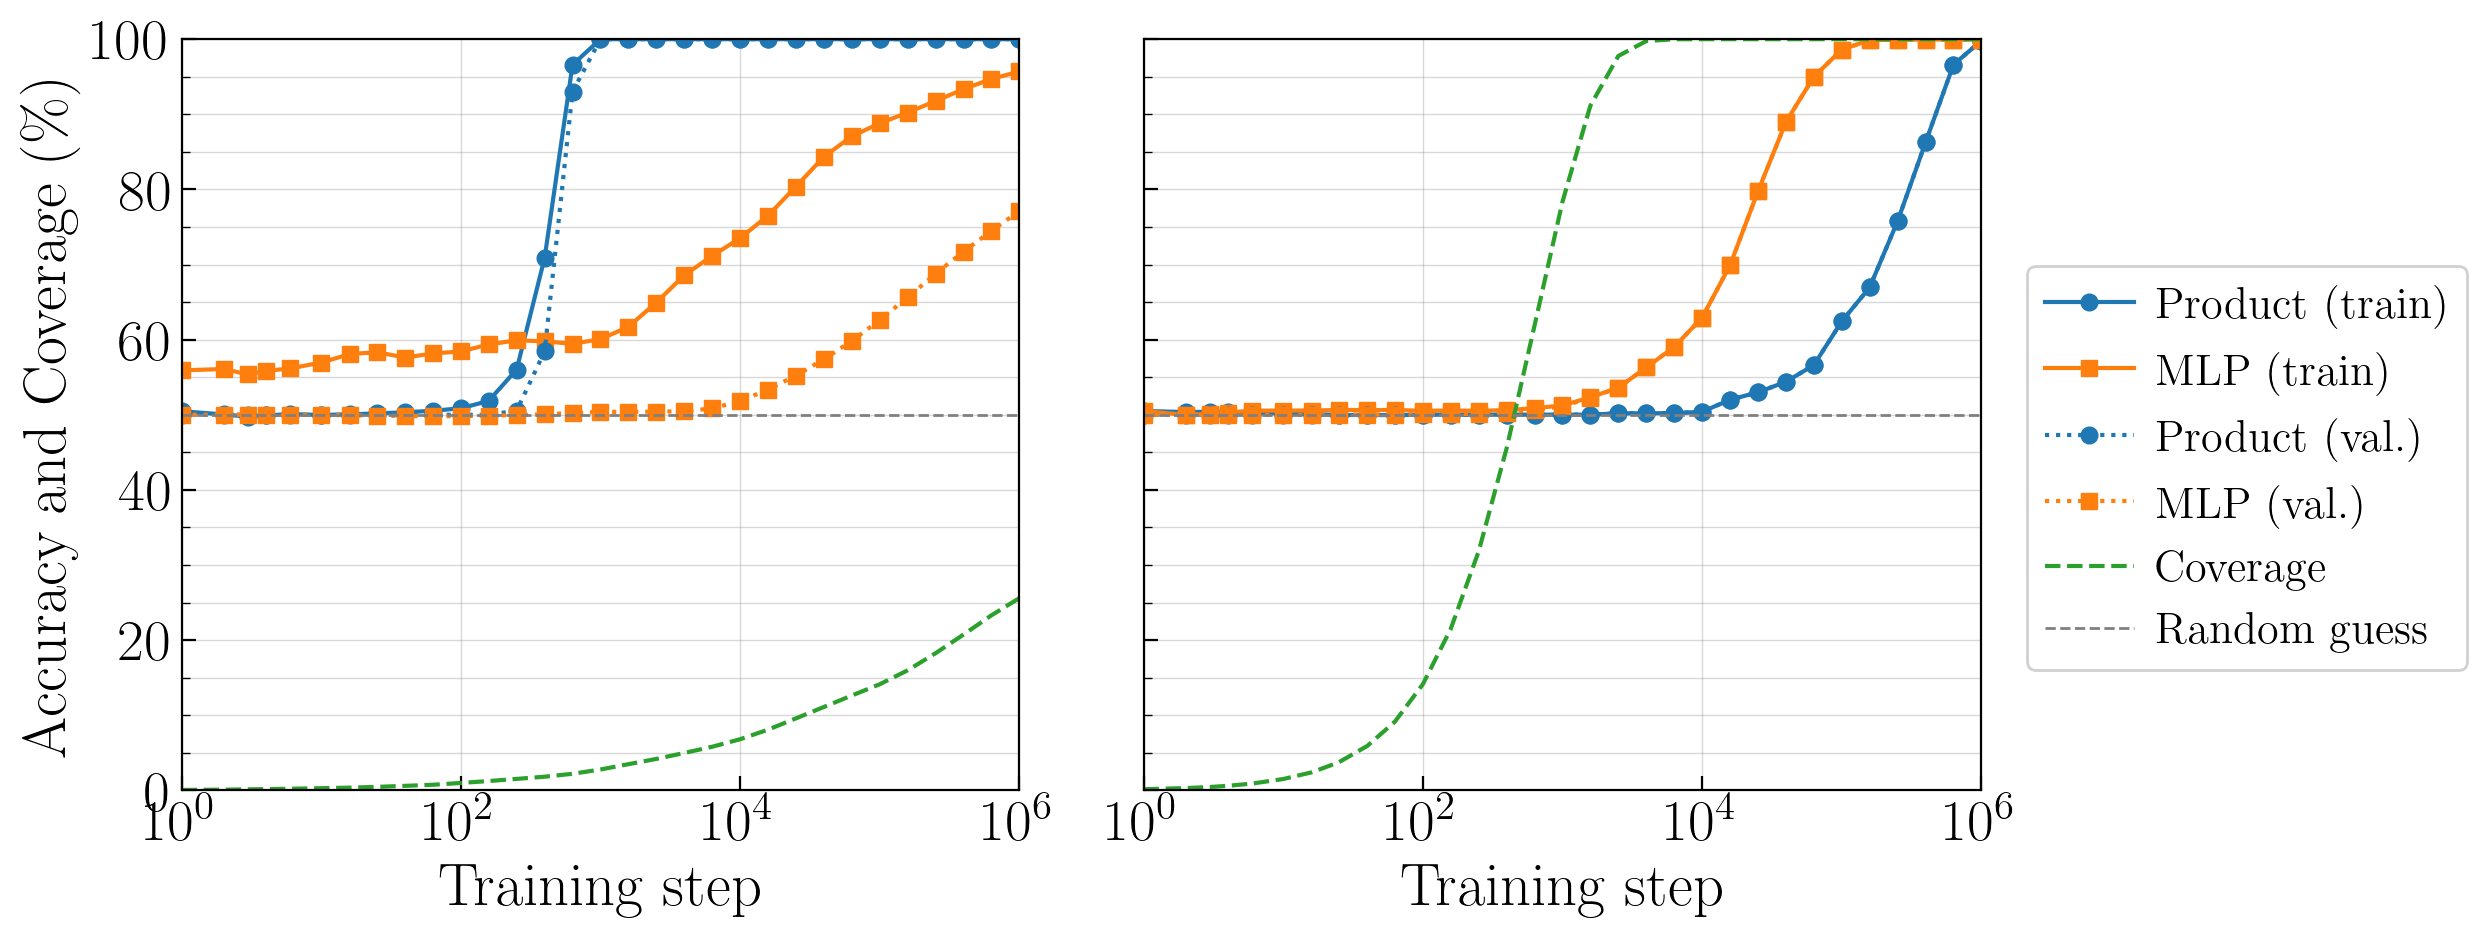

In [3]:
fig, (ax_sp, ax_fu) = plt.subplots(
    1, 
    2, 
    figsize=(
        plt.rcParams['figure.figsize'][0] * 1.5,
        plt.rcParams['figure.figsize'][1] * 1
    ), 
    sharey=True)

color_prod = 'tab:blue'
color_mlp  = 'tab:orange'
color_cov  = 'tab:green'

for ax, regime, prod_tr, mlp_tr, prod_val, mlp_val, cov, title in [
    (ax_sp, 'sparse',
     sparse_product_train_acc, sparse_mlp_train_acc,
     sparse_product_val_acc,   sparse_mlp_val_acc,
     sparse_coverage,          r'Sparse Regime ($p_e = 1/N$)'),
    (ax_fu, 'full',
     full_product_train_acc,   full_mlp_train_acc,
     full_product_val_acc,     full_mlp_val_acc,
     full_coverage,            r'Dense Regime (uniform)'),
]:
    # Mean and std across runs
    pt_m, pt_s = prod_tr.mean(0),  prod_tr.std(0)
    mt_m, mt_s = mlp_tr.mean(0),   mlp_tr.std(0)
    pv_m, pv_s = prod_val.mean(0), prod_val.std(0)
    mv_m, mv_s = mlp_val.mean(0),  mlp_val.std(0)

    # Training accuracy (solid)
    ax.plot(eval_steps, pt_m, color=color_prod, ls='-', marker='o', label='Product (train)')
    #ax.fill_between(eval_steps, pt_m - pt_s, pt_m + pt_s, color=color_prod, alpha=0.12)
    ax.plot(eval_steps, mt_m, color=color_mlp, ls='-', marker='s', label='MLP (train)')
    #ax.fill_between(eval_steps, mt_m - mt_s, mt_m + mt_s, color=color_mlp, alpha=0.12)

    # Validation accuracy (dashed)
    ax.plot(eval_steps, pv_m, color=color_prod, ls=':', marker='o', label='Product (val.)')
    #ax.fill_between(eval_steps, pv_m - pv_s, pv_m + pv_s, color=color_prod, alpha=0.08)
    ax.plot(eval_steps, mv_m, color=color_mlp, ls=':', marker='s', label='MLP (val.)')
    #ax.fill_between(eval_steps, mv_m - mv_s, mv_m + mv_s, color=color_mlp, alpha=0.08)

    # Coverage (dotted, same axis)
    cov_m = 100 * cov.mean(0)
    cov_s = 100 * cov.std(0)
    ax.plot(eval_steps, cov_m, color=color_cov, ls='--', label='Coverage')
    #ax.fill_between(eval_steps, cov_m - cov_s, cov_m + cov_s, color=color_cov, alpha=0.10)

    # Random guess baseline
    ax.axhline(50, color='grey', ls='--', lw=1.0, label='Random guess')

    ax.set_xlabel('Training step')
    ax.set_xscale('log')
    ax.set_xlim(1, eval_steps[-1])
    ax.set_ylim(0, 100)
    #ax.set_title(title)

# Left plot gets the y-label
ax_sp.set_ylabel('Accuracy and Coverage (\\%)')

# Single shared legend outside both plots
handles, labels = ax_sp.get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.2, 0.5))

plt.tight_layout()
plt.show()